На базе баскетбольных матчей добейтесь средней абсолютной ошибки 17 и менее очков.

In [1]:
import re

import gdown
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler

from tensorflow.keras.layers import (
    BatchNormalization,
    Dense,
    Dropout,
    Input,
    concatenate,
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.text import Tokenizer

%matplotlib inline

In [2]:
DATA_URL = 'https://storage.yandexcloud.net/aiueducation/Content/base/l10/basketball.csv'
DATA_FILE = 'basketball.csv'

gdown.download(DATA_URL, DATA_FILE, quiet=True)

basket_df = pd.read_csv(
    DATA_FILE,
    encoding='cp1251',
    sep=';',
    header=0,
    index_col=0
)

basket_df.head()

,TOTAL,info,Ком. 1,Ком. 2,Минута,Общая минута,Секунда,fcount,ftime
0,"98,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,0.0,1,1.0,30,81,90.0
1,"100,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,2.0,1,1.0,45,81,105.0
2,"99,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,2.0,2,2.0,0,81,120.0
3,"98,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,2.0,2,2.0,30,81,150.0
4,"95,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,2.0,3,3.0,0,81,180.0


In [3]:
match_notes = basket_df['info'].values

print('Количество текстовых записей:', len(match_notes))

Количество текстовых записей: 52450


In [4]:
# Настройки токена
MAX_WORDS = 5000
TEXT_FILTERS = '!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'


def make_tokenizer(texts, vocab_size=MAX_WORDS):
    tok = Tokenizer(
        num_words=vocab_size,
        filters=TEXT_FILTERS,
        lower=True,
        split=' ',
        oov_token='unknown',
        char_level=False
    )
    tok.fit_on_texts(texts)
    return tok


tokenizer = make_tokenizer(match_notes)

In [5]:
def texts_to_bow(texts, tok):
    sequences = tok.texts_to_sequences(texts)
    return tok.sequences_to_matrix(sequences)


xBOW_text = texts_to_bow(match_notes, tokenizer)

In [6]:
# Числовые признаки матча и целевой результат
NUMERIC_COLUMNS = ['Ком. 1', 'Ком. 2', 'Минута', 'Секунда', 'ftime']
TARGET_COLUMN = 'fcount'


def get_numeric_dataset(dataframe):
    features = dataframe[NUMERIC_COLUMNS].astype('int').to_numpy()
    target = dataframe[TARGET_COLUMN].astype('int').to_numpy()
    return features, target


xTrain, yTrain = get_numeric_dataset(basket_df)

print('Числовые признаки:', xTrain.shape)
print('Целевые значения:', yTrain.shape)
print('Текстовая матрица:', xBOW_text.shape)

Числовые признаки: (52450, 5)
Целевые значения: (52450,)
Текстовая матрица: (52450, 5000)


In [7]:
def show_mae_for_two_inputs(model, x_num, x_text, y_true, plot=False):
    y_pred = model.predict([x_num, x_text], verbose=0).squeeze()
    mae = np.mean(np.abs(y_true - y_pred))
    percent = mae / y_true.mean(axis=0) * 100

    print(
        'Средняя абсолютная ошибка {:.3f} очков, это {:.3f}% от средней суммы очков по {} играм'.format(
            mae,
            percent,
            len(x_num)
        )
    )

    if plot:
        plt.figure(figsize=(7, 7))
        plt.scatter(y_true, y_pred, alpha=0.5)
        plt.xlabel('Правильные значения')
        plt.ylabel('Предсказания')
        plt.axis('equal')
        plt.plot([0, 250], [0, 250])
        plt.show()

    return mae

In [8]:
# Масштабируем числовые признаки
scaler = StandardScaler()
xTrain_scaled = scaler.fit_transform(xTrain)

def build_score_model(num_shape, text_shape):
    numeric_input = Input(shape=(num_shape,), name='numeric_data')
    num_branch = Dense(128, activation='relu')(numeric_input)
    num_branch = BatchNormalization()(num_branch)
    num_branch = Dense(64, activation='relu')(num_branch)

    text_input = Input(shape=(text_shape,), name='text_bow')
    text_branch = Dense(512, activation='relu')(text_input)
    text_branch = Dropout(0.4)(text_branch)
    text_branch = Dense(256, activation='relu')(text_branch)
    text_branch = Dropout(0.3)(text_branch)

    merged = concatenate([num_branch, text_branch])

    hidden = Dense(128, activation='relu')(merged)
    hidden = Dense(64, activation='relu')(hidden)
    hidden = Dense(32, activation='relu')(hidden)

    score_output = Dense(1, activation='linear', name='score_prediction')(hidden)

    return Model(
        inputs=[numeric_input, text_input],
        outputs=score_output
    )

model_final = build_score_model(
    num_shape=xTrain_scaled.shape[1],
    text_shape=xBOW_text.shape[1]
)

In [9]:
model_final.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

model_final.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_bow            │ (None, 5000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_data        │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │  2,560,512 │ text_bow[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │        768 │ numeric_data[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 320)       │          0 │ dense_1[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     41,088 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      8,256 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │      2,080 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ score_prediction    │ (None, 1)         │         33 │ dense_6[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,752,833 (10.50 MB)

 Trainable params: 2,752,577 (10.50 MB)

 Non-trainable params: 256 (1.00 KB)

In [10]:
# Обучаем модель
history = model_final.fit(
    [xTrain_scaled, xBOW_text],
    yTrain,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/30
738/738 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 1265.8528 - mae: 16.2669 - val_loss: 1051.4432 - val_mae: 22.2727
Epoch 2/30
738/738 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 62.8381 - mae: 6.2006 - val_loss: 892.7079 - val_mae: 20.0095
Epoch 3/30
738/738 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 47.8401 - mae: 5.4127 - val_loss: 850.3745 - val_mae: 18.6094
Epoch 4/30
738/738 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 41.1511 - mae: 5.0497 - val_loss: 758.0432 - val_mae: 17.8461
Epoch 5/30
738/738 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 33.1330 - mae: 4.5305 - val_loss: 799.3835 - val_mae: 17.8509
Epoch 6/30
738/738 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 30.5209 - mae: 4.3277 - val_loss: 778.9362 - val_mae: 17.8743
Epoch 7/30
738/738 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 25.4534 - mae: 3.9508 - val_loss: 783.5096 - val_mae: 17.9981
Epoch 8/30
738/738 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 23.3398 - mae: 3.7826 - val_loss: 773.5780 - val_mae: 17.2035
Epoch 9/30
738/738

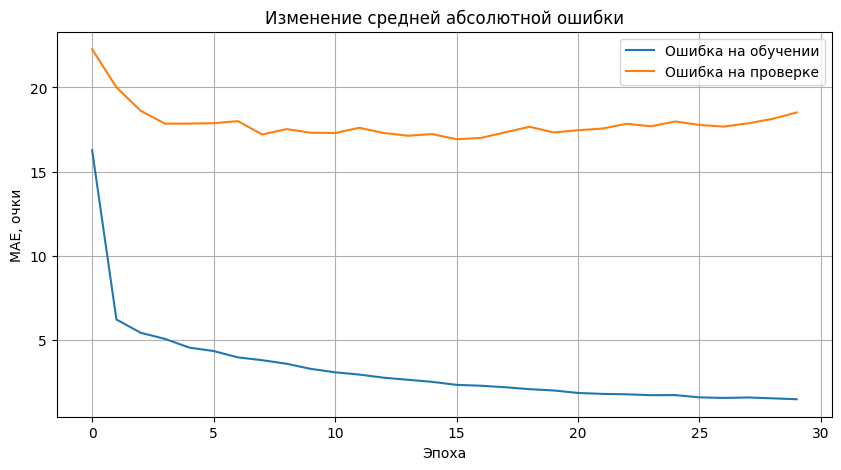

In [11]:
def plot_training_mae(train_history):
    plt.figure(figsize=(10, 5))
    plt.plot(train_history.history['mae'], label='Ошибка на обучении')
    plt.plot(train_history.history['val_mae'], label='Ошибка на проверке')
    plt.xlabel('Эпоха')
    plt.ylabel('MAE, очки')
    plt.title('Изменение средней абсолютной ошибки')
    plt.legend()
    plt.grid(True)
    plt.show()


plot_training_mae(history)

Итоговая средняя ошибка (MAE): 3.54 очков
Ошибка менее 17.
Средняя абсолютная ошибка 3.537 очков, это 2.333% от средней суммы очков по 52450 играм


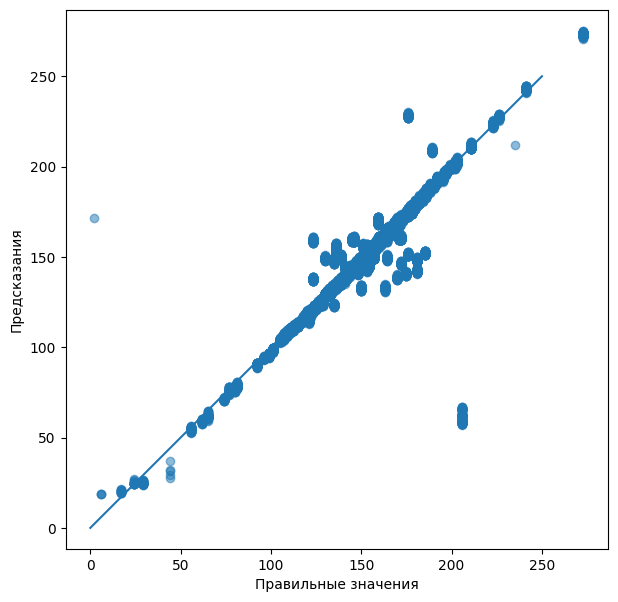

np.float64(3.5374148307923936)

In [12]:
# проверка качества модели
final_mae = model_final.evaluate(
    [xTrain_scaled, xBOW_text],
    yTrain,
    verbose=0
)[1]

print(f'Итоговая средняя ошибка (MAE): {round(final_mae, 2)} очков')

if final_mae <= 17:
    print('Ошибка менее 17.')
else:
    print('Нужно еще немного дообучить или усложнить модель.')

show_mae_for_two_inputs(
    model_final,
    xTrain_scaled,
    xBOW_text,
    yTrain,
    plot=True
)

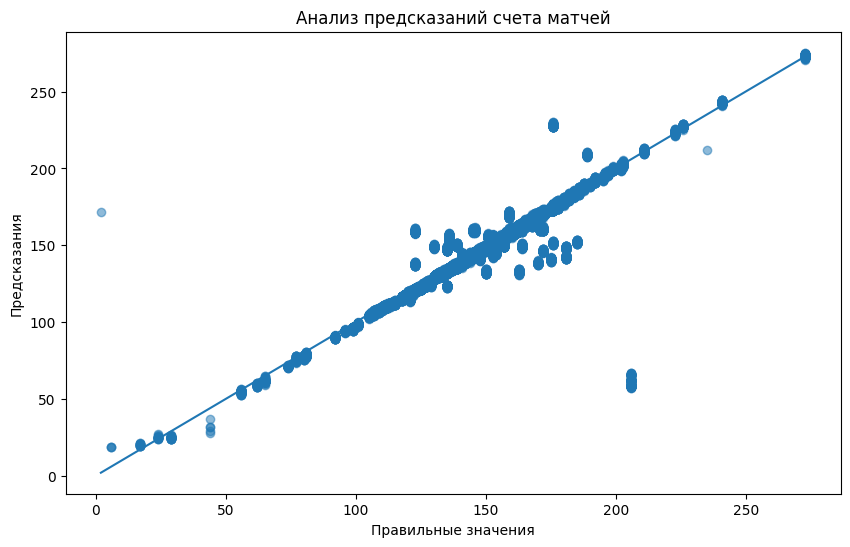

In [13]:
# Сравнение правильных значений
predictions = model_final.predict([xTrain_scaled, xBOW_text], verbose=0).squeeze()

plt.figure(figsize=(10, 6))
plt.scatter(yTrain, predictions, alpha=0.5)
plt.plot(
    [min(yTrain), max(yTrain)],
    [min(yTrain), max(yTrain)]
)
plt.xlabel('Правильные значения')
plt.ylabel('Предсказания')
plt.title('Анализ предсказаний счета матчей')
plt.show()